In [3]:
#importar
import pandas as pd

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Cargamos dataset sucio 
dfSucio = pd.read_csv("dataset_sucio_practica.csv")

In [10]:
dfSucio.shape

(125, 8)

In [15]:
dfSucio.head()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [14]:
dfSucio.tail()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
124,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [16]:
dfSucio.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [24]:
#Mostrar datos de los id 29,55,58
dfSucio[dfSucio["id"].isin([29,55,58])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN
57,58,Michael Barajas,40.0,antoniocox@hotmail.com,España,15000.0,2026-05-02,NaN


In [27]:
#Generamos una copia "por cualquier cosa"
dfCopy = dfSucio.copy()

In [26]:
dfSucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


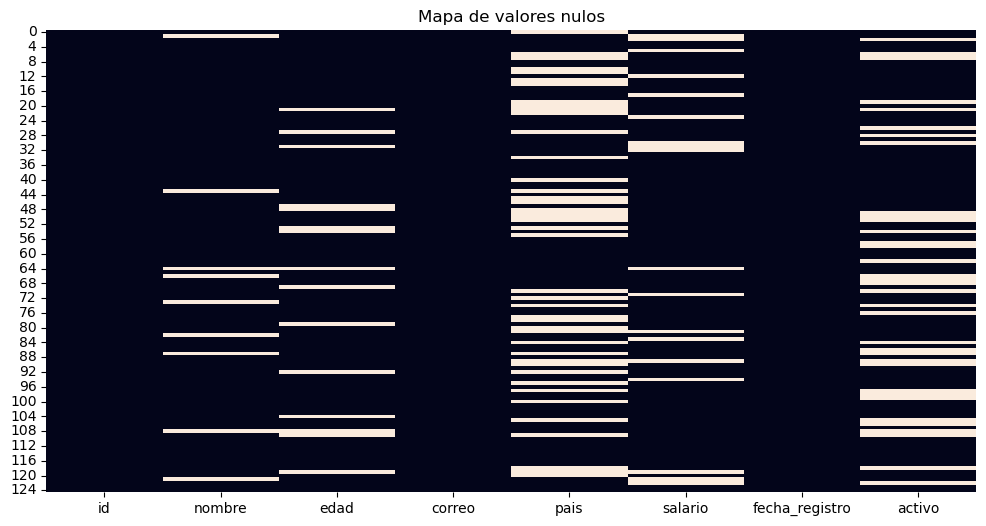

In [28]:
plt.figure(figsize = (12,6))
sns.heatmap(dfSucio.isnull(), cbar = False)
plt.title("Mapa de valores nulos") 
plt.show()

In [31]:
#Limpieza de datos 
#Valores duplicados
dfSucio.duplicated().sum()

np.int64(0)

In [30]:
#Borrar los duplicados (Inplace hace que se reescriba el dataset y no se cree uno nuevo) 
dfSucio.drop_duplicates(inplace = True)

In [32]:
#Corregir edades inválidas
dfSucio[(dfSucio["edad"] <0) | (dfSucio["edad"]>110)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [39]:
#Ponemos los valores como NaN para los que están mal 
dfSucio.loc[(dfSucio["edad"]<0) | (dfSucio["edad"]>110), "edad"] = np.nan

In [40]:
dfSucio[(dfSucio["edad"] <0) | (dfSucio["edad"]>110)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [41]:
#Calcular variable de la edad 
mediana_edad = dfSucio ["edad"].median()

In [42]:
mediana_edad

30.0

In [43]:
dfSucio["edad"] = dfSucio["edad"].fillna(mediana_edad)

In [44]:
dfSucio["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [45]:
#Correbimos anomalía de salarios negativos 
dfSucio[dfSucio ["salario"]<0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [46]:
dfSucio.loc[(dfSucio["salario"]<0), "salario"] = np.nan

In [47]:
dfSucio[dfSucio ["salario"]<0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [48]:
mediana_salario = dfSucio["salario"].median()

In [49]:
mediana_salario

15000.0

In [50]:
dfSucio["salario"] = dfSucio["salario"].fillna(mediana_salario)

In [51]:
dfSucio["salario"].describe

<bound method NDFrame.describe of 0      25000.0
1      15000.0
2      15000.0
3      25000.0
4      25000.0
        ...   
115    12000.0
116    18000.0
117    12000.0
118    15000.0
119    15000.0
Name: salario, Length: 120, dtype: float64>

In [53]:
#Corregir correos "NO válidos" ("~" sirve para el arroba)
dfSucio[~dfSucio["correo"].str.contains("@", na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,correo_invalido,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,correo_invalido,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,correo_invalido,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,correo_invalido,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,correo_invalido,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,correo_invalido,Argentina,12000.0,2024-11-16,Sí


In [55]:
#correos no válidos
correo_invalido = ~dfSucio["correo"].str.contains("@", na = False)
dfSucio.loc[correo_invalido, "correo"] = pd.NA

In [56]:
dfSucio[~dfSucio["correo"].str.contains("@", na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,<NA>,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,<NA>,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,<NA>,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,<NA>,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,<NA>,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,<NA>,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,<NA>,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,<NA>,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,<NA>,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,<NA>,Argentina,12000.0,2024-11-16,Sí


In [58]:
#Corregir paises no asignados 
dfSucio["pais"].isnull().sum()

np.int64(42)

In [59]:
moda_pais = dfSucio["pais"].mode()[0]

In [60]:
moda_pais

'Argentina'

In [61]:
dfSucio["pais"] = dfSucio["pais"].fillna(moda_pais)

In [62]:
dfSucio["pais"].isnull().sum()

np.int64(0)

In [63]:
dfSucio.dtypes

id                  int64
nombre             object
edad              float64
correo             object
pais               object
salario           float64
fecha_registro     object
activo             object
dtype: object

In [64]:
#Convertimos fecha de object a datetime 
dfSucio["fecha_registro"] = pd.to_datetime(dfSucio["fecha_registro"])

In [65]:
dfSucio.dtypes

id                         int64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
dtype: object

In [69]:
dfSucio["fecha_registro"].dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [71]:
#Categorizar el campo activo 
dfSucio["activo"].value_counts(dropna = False)

activo
Sí     47
No     39
NaN    34
Name: count, dtype: int64

In [72]:
dfSucio["activo"] = dfSucio ["activo"].fillna("Sí")

In [73]:
dfSucio["activo"].value_counts(dropna = False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [76]:
#Convertimos a binario 
dfSucio["activo"] = dfSucio ["activo"].map({
    "Sí":1, 
    "No":0 
})

In [77]:
dfSucio["activo"].value_counts(dropna = False)

activo
1    81
0    39
Name: count, dtype: int64

In [79]:
(dfSucio.isnull().sum()/len(dfSucio) * 100)

id                 0.000000
nombre             6.666667
edad               0.000000
correo            10.000000
pais               0.000000
salario            0.000000
fecha_registro     0.000000
activo             0.000000
dtype: float64

Conclusiones

Durante la práctica se identificaron y se corrigieron los siguientes problemas: 
1. Borrar datos duplicados
2. Corregir datos no válidos y atípicos
3. Realizar y corregir tipos de datos
4. Categorizar campos que sean necesarios 